## **Dataset Label Extraction**

In [ ]:
import os
import pandas as pd

base_dir = "/content/drive/MyDrive/SER"

emotion_map = {
    # RAVDESS codes
    "01": "neutral",
    "02": "calm",
    "03": "happy",
    "04": "sad",
    "05": "angry",
    "06": "fearful",
    "07": "disgust",
    "08": "surprised",

    # TESS keywords
    "angry": "angry",
    "disgust": "disgust",
    "fear": "fearful",
    "happy": "happy",
    "neutral": "neutral",
    "pleasant": "pleasant",
    "sad": "sad",

    # SAVEE suffixes
    "_a": "angry",
    "_d": "disgust",
    "_f": "fearful",
    "_h": "happy",
    "_n": "neutral",
    "_sa": "sad",
    "_su": "surprised"
}

data = []

# Walk through all subdirectories and collect files
for root, _, files in os.walk(base_dir):
    for file in files:
        if file.lower().endswith(('.wav', '.mp3')):
            emotion = "unknown"
            for key, val in emotion_map.items():
                if key in file.lower():
                    emotion = val
                    break
            data.append({
                "filepath": os.path.join(root, file),
                "filename": file,
                "emotion": emotion
            })

df = pd.DataFrame(data)
df.to_csv(os.path.join(base_dir, "emotion_labels.csv"), index=False)

print(" Labels saved to emotion_labels.csv")
print(df['emotion'].value_counts())


 Labels saved to emotion_labels.csv
emotion
neutral      3764
unknown      1153
disgust       915
happy         904
fearful       897
sad           877
angry         856
surprised      68
calm           56
Name: count, dtype: int64


## **Relabel SAVEE**

In [ ]:
import pandas as pd

labels_path = '/content/drive/MyDrive/SER/emotion_labels.csv'
labels_df = pd.read_csv(labels_path)

def relabel_savee(filename):
    fname = filename.lower()
    if fname.startswith("a"):
        return "angry"
    elif fname.startswith("d"):
        return "disgust"
    elif fname.startswith("f"):
        return "fearful"
    elif fname.startswith("h"):
        return "happy"
    elif fname.startswith("n"):
        return "neutral"
    elif fname.startswith("sa"):
        return "sad"
    elif fname.startswith("su"):
        return "surprised"
    else:
        return "unknown"

labels_df['emotion'] = labels_df.apply(
    lambda row: relabel_savee(row['filename']) if row['emotion'] == 'unknown' else row['emotion'],
    axis=1
)

labels_df.to_csv(labels_path, index=False)
print("SAVEE unknowns relabeled successfully!")
print(labels_df['emotion'].value_counts())


SAVEE unknowns relabeled successfully!
emotion
neutral      3940
disgust       971
happy         960
fearful       953
sad           933
angry         912
unknown       641
surprised     124
calm           56
Name: count, dtype: int64


In [ ]:
# Centroid-based nearest labeling (Final Optimized)

import os, numpy as np, pandas as pd, librosa
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm
from scipy.spatial.distance import cdist

labels_csv = '/content/drive/MyDrive/SER/emotion_labels.csv'
df = pd.read_csv(labels_csv)

# Split into known and unknown
known_df = df[df['emotion'] != 'unknown'].reset_index(drop=True)
unknown_df = df[df['emotion'] == 'unknown'].reset_index(drop=True)

def get_feature(path, duration=3):
    """Safely extract MFCC + delta features for each file."""
    if not os.path.exists(path):
        print("⚠️ Missing file:", path)
        return None
    try:
        y, sr = librosa.load(path, sr=None, mono=True)
        if len(y) < sr * duration:
            y = np.pad(y, (0, sr * duration - len(y)))
        else:
            y = y[:sr * duration]
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)
        delta = librosa.feature.delta(mfcc)
        feat = np.hstack([np.mean(mfcc, axis=1), np.mean(delta, axis=1)])
        return feat
    except Exception as e:
        print("Error loading:", path, "|", e)
        return None

# Compute features for labeled files
print("Computing features for labeled files...")
known_feats = [get_feature(p) for p in tqdm(known_df['filepath'].values)]
known_df['feat'] = known_feats
known_df = known_df[known_df['feat'].notnull()].reset_index(drop=True)

if known_df.empty:
    raise ValueError(" No valid known features found. Check file paths or audio formats.")

# Compute centroids per emotion
print("Computing class centroids...")
scaler = StandardScaler()
all_feats = np.vstack(known_df['feat'].values)
scaler.fit(all_feats)
known_df['feat_scaled'] = list(scaler.transform(all_feats))

centroids = {
    emo: np.mean(np.vstack(group['feat_scaled'].values), axis=0)
    for emo, group in known_df.groupby('emotion')
}

# Assign nearest centroid for unknown files
if not unknown_df.empty:
    print("Assigning unknown files to nearest centroid...")
    unknown_feats = [get_feature(p) for p in tqdm(unknown_df['filepath'].values)]
    unknown_df['feat'] = unknown_feats
    unknown_df = unknown_df[unknown_df['feat'].notnull()].reset_index(drop=True)

    if not unknown_df.empty:
        unknown_X = scaler.transform(np.vstack(unknown_df['feat'].values))
        centroid_matrix = np.vstack(list(centroids.values()))
        centroid_labels = list(centroids.keys())

        dists = cdist(unknown_X, centroid_matrix, metric='euclidean')
        nearest_idx = np.argmin(dists, axis=1)
        nearest_label = [centroid_labels[i] for i in nearest_idx]
        nearest_dist = dists[np.arange(dists.shape[0]), nearest_idx]

        # Threshold = mean + 1 std of within-class distances
        within = []
        for emo, group in known_df.groupby('emotion'):
            feats = np.vstack(group['feat_scaled'].values)
            d = np.linalg.norm(feats - centroids[emo], axis=1)
            within.extend(d.tolist())
        threshold = np.mean(within) + np.std(within)

        unknown_df['pred_label'] = nearest_label
        unknown_df['dist'] = nearest_dist
        unknown_df['confidence'] = 1 / (1 + unknown_df['dist'])
        unknown_df['auto_label'] = unknown_df.apply(
            lambda r: r['pred_label'] if r['dist'] <= threshold else 'REVIEW',
            axis=1
        )

        for idx, row in unknown_df.iterrows():
            df.loc[df['filepath'] == row['filepath'], 'emotion'] = row['auto_label']

        save_path = '/content/drive/MyDrive/SER/emotion_labels_auto_centroid.csv'
        df.to_csv(save_path, index=False)
        print(f"\n Saved: {save_path}")
        print("Auto-label summary:\n", unknown_df['auto_label'].value_counts())
    else:
        print(" No usable unknown audio files found.")
else:
    print(" No unknown files to process.")


Computing features for labeled files...


100%|██████████| 8849/8849 [1:19:52<00:00,  1.85it/s]


Computing class centroids...
Assigning unknown files to nearest centroid...


100%|██████████| 641/641 [05:45<00:00,  1.86it/s]



 Saved: /content/drive/MyDrive/SER/emotion_labels_auto_centroid.csv
Auto-label summary:
 auto_label
happy      310
disgust    284
angry       39
REVIEW       8
Name: count, dtype: int64


## **preprocessing**

In [ ]:
# Speech Emotion Recognition - Fast Preprocessing Pipeline

import os
import numpy as np
import pandas as pd
import librosa
from joblib import Parallel, delayed
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from tqdm import tqdm

# Data Preprocessing
def preprocess_audio(file_path, target_sr=16000, duration=3):
    try:
        y, sr = librosa.load(file_path, sr=target_sr, mono=True)
        y = librosa.util.fix_length(y, size=target_sr * duration)
        y = librosa.util.normalize(y)
        return y
    except Exception:
        return None

# Feature Extraction (MFCC + Chroma + Mel)
def extract_features(file_path):
    y = preprocess_audio(file_path)
    if y is None:
        return None
    sr = 16000
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)
    chroma = librosa.feature.chroma_stft(y=y, sr=sr)
    mel = librosa.feature.melspectrogram(y=y, sr=sr)
    return np.hstack([
        np.mean(mfcc, axis=1),
        np.mean(chroma, axis=1),
        np.mean(mel, axis=1)
    ])

# Load Dataset
labels_path = '/content/drive/MyDrive/SER/emotion_labels.csv'
data = pd.read_csv(labels_path)

# Parallel Feature Extraction (8 workers)
print("Extracting features in parallel... ⏳")

results = Parallel(n_jobs=8, backend='loky')(
    delayed(extract_features)(fp) for fp in tqdm(data['filepath'])
)

# Filter out any None entries
valid_idx = [i for i, feat in enumerate(results) if feat is not None]
X = np.array([results[i] for i in valid_idx])
y = data.iloc[valid_idx]['emotion'].values

print(f" Features extracted: {X.shape}")

# PCA (Dimensionality Reduction)
pca = PCA(n_components=0.99, random_state=42)
X_pca = pca.fit_transform(X)
print(f" PCA reduced shape: {X_pca.shape}")

# Encode Labels
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)
print(" Labels encoded:", list(encoder.classes_))

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)
print(f" Split done: Train={len(X_train)}, Test={len(X_test)}")

# Save for later reuse
np.save('/content/drive/MyDrive/SER/features_X.npy', X_pca)
np.save('/content/drive/MyDrive/SER/labels_y.npy', y_encoded)
print("Saved preprocessed data to Drive!")


Extracting features in parallel... ⏳


100%|██████████| 9490/9490 [03:59<00:00, 39.64it/s]


 Features extracted: (9490, 180)
 PCA reduced shape: (9490, 41)
 Labels encoded: ['angry', 'calm', 'disgust', 'fearful', 'happy', 'neutral', 'sad', 'surprised', 'unknown']
 Split done: Train=7592, Test=1898
Saved preprocessed data to Drive!


## **SMOTE Oversampling**

In [ ]:
# SMOTE Oversampling (Multi-class Fix)

from imblearn.over_sampling import SMOTE
import numpy as np

print(" Applying SMOTE on training data...")

# Flatten X_train from 3D → 2D
X_train_2d = X_train.reshape(X_train.shape[0], -1)

# SMOTE for multi-class (balances all minority classes)
sm = SMOTE(sampling_strategy='auto', random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train_2d, y_train)

# Safe reshape for both 2D and 3D inputs
if len(X_train.shape) == 3:
    X_train_res = X_train_res.reshape(X_train_res.shape[0], X_train.shape[1], X_train.shape[2])
else:
    # If already 2D, just keep as is
    X_train_res = X_train_res

print(f" Before SMOTE: {X_train.shape[0]} samples")
print(f" After SMOTE:  {X_train_res.shape[0]} samples")
print(" SMOTE balancing completed successfully!")


 Applying SMOTE on training data...
 Before SMOTE: 7592 samples
 After SMOTE:  28368 samples
 SMOTE balancing completed successfully!


## **1D CNN**

In [ ]:
# Optimized 1D CNN for Speech Emotion Recognition

import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Dropout, Flatten, Dense, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score

# Load processed data (from Drive)

X = np.load('/content/drive/MyDrive/SER/features_X.npy')
y = np.load('/content/drive/MyDrive/SER/labels_y.npy')

# Train–Test Split (if not already done)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Reshape for 1D CNN (samples, timesteps, features)
X_train = np.expand_dims(X_train, axis=-1)
X_test = np.expand_dims(X_test, axis=-1)

print(" Data reshaped for 1D CNN:", X_train.shape)

# Build Optimized 1D CNN Model
model = Sequential([
    Conv1D(256, 5, activation='relu', padding='same', input_shape=(X_train.shape[1], 1)),
    BatchNormalization(),
    MaxPooling1D(2),
    Dropout(0.3),

    Conv1D(128, 5, activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling1D(2),
    Dropout(0.3),

    Conv1D(64, 3, activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling1D(2),
    Dropout(0.3),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.4),
    Dense(len(np.unique(y)), activation='softmax')
])

# Compile Model
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0008)
model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model.summary()

# Callbacks for Optimization
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)

# Train the Model
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=64,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# Evaluate the Model
y_pred = np.argmax(model.predict(X_test), axis=1)
test_acc = accuracy_score(y_test, y_pred)
train_acc = history.history['accuracy'][-1]

print("\n Train Accuracy:", round(train_acc * 100, 2), "%")
print(" Test Accuracy:", round(test_acc * 100, 2), "%")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Save Model
model.save('/content/drive/MyDrive/SER/Models/Optimized_CNN_SER.h5')
print(" Model saved successfully to Drive!")


 Data reshaped for 1D CNN: (7592, 41, 1)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 41, 256)        │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 41, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 20, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 20, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 20, 128)        │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 20, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 10, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 10, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 10, 64)         │        24,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 10, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 5, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 5, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 320)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 9)              │         1,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 234,185 (914.79 KB)

 Trainable params: 233,289 (911.29 KB)

 Non-trainable params: 896 (3.50 KB)

Epoch 1/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 16s 67ms/step - accuracy: 0.3307 - loss: 2.2352 - val_accuracy: 0.6359 - val_loss: 1.1652 - learning_rate: 8.0000e-04
Epoch 2/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6220 - loss: 1.1662 - val_accuracy: 0.8038 - val_loss: 0.6658 - learning_rate: 8.0000e-04
Epoch 3/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7220 - loss: 0.8772 - val_accuracy: 0.8374 - val_loss: 0.5287 - learning_rate: 8.0000e-04
Epoch 4/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7824 - loss: 0.7146 - val_accuracy: 0.8604 - val_loss: 0.4488 - learning_rate: 8.0000e-04
Epoch 5/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7915 - loss: 0.6492 - val_accuracy: 0.8670 - val_loss: 0.4141 - learning_rate: 8.0000e-04
Epoch 6/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8087 - loss: 0.5953 - val_accuracy: 0.8802 - val_loss: 0.3751 - learning_rate: 8.0000e-04
Epoch 7/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8254 - los


 Train Accuracy: 95.14 %
 Test Accuracy: 94.47 %

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.96      0.95       182
           1       1.00      0.64      0.78        11
           2       0.96      0.89      0.92       194
           3       0.96      0.95      0.96       191
           4       0.95      0.90      0.92       192
           5       0.98      0.97      0.98       788
           6       0.94      0.95      0.94       187
           7       0.61      0.56      0.58        25
           8       0.80      0.98      0.88       128

    accuracy                           0.94      1898
   macro avg       0.90      0.87      0.88      1898
weighted avg       0.95      0.94      0.94      1898

 Model saved successfully to Drive!


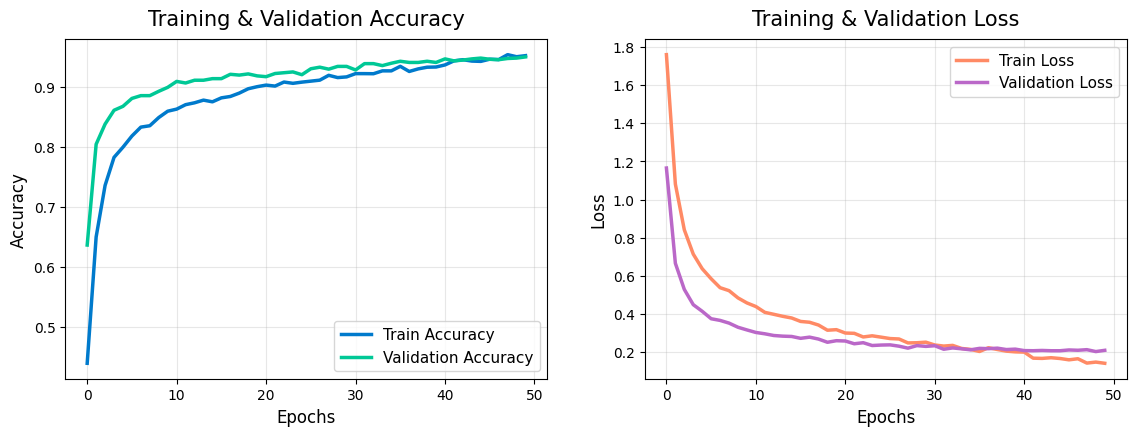

60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


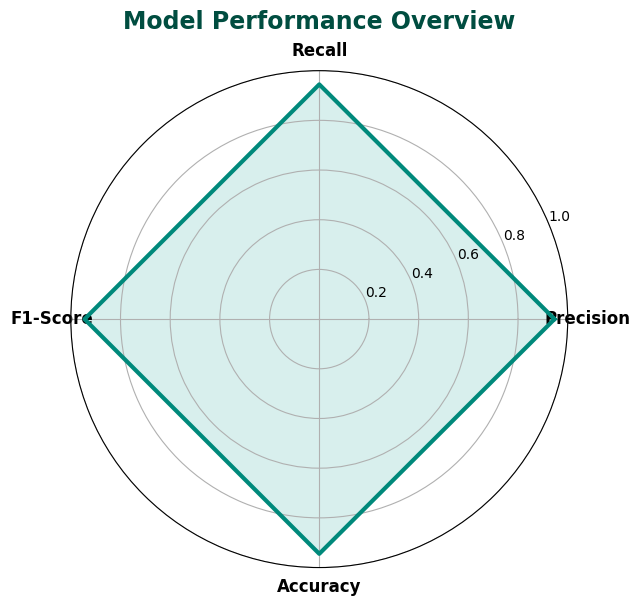

In [ ]:
# Model Performance Visualization (Radar + Curves)
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score


# Training Curves
plt.figure(figsize=(12, 5))

# Accuracy curve
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', linewidth=2.5, color='#007acc')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2.5, color='#00c896')
plt.title('Training & Validation Accuracy', fontsize=15, pad=10)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)

# Loss curve
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', linewidth=2.5, color='#ff8a65')
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2.5, color='#ba68c8')
plt.title('Training & Validation Loss', fontsize=15, pad=10)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)

plt.tight_layout(pad=3)
plt.show()


# Clean Radar Plot for Metrics

y_pred = np.argmax(model.predict(X_test), axis=1)

precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
accuracy = accuracy_score(y_test, y_pred)

metrics = [precision, recall, f1, accuracy]
labels = ['Precision', 'Recall', 'F1-Score', 'Accuracy']

# Radar setup
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
metrics += metrics[:1]
angles += angles[:1]

plt.figure(figsize=(7, 7))
ax = plt.subplot(111, polar=True)
ax.plot(angles, metrics, color='#00897b', linewidth=3)
ax.fill(angles, metrics, color='#80cbc4', alpha=0.3)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_ylim(0, 1)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=12, fontweight='bold')
ax.set_title("Model Performance Overview", fontsize=17, pad=30, fontweight='bold', color='#004d40')
plt.tight_layout(pad=3)
plt.show()


## **CNN + BiLSTM**

In [ ]:
# CNN + LSTM (Safe SMOTE + No Data Leakage)
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from imblearn.over_sampling import SMOTE

# Split BEFORE SMOTE
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Apply SMOTE only on TRAIN
if X_train.ndim == 3:
    X_train_flat = X_train.reshape(X_train.shape[0], -1)
else:
    X_train_flat = X_train

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train_flat, y_train)

# Reshape for CNN-LSTM
input_dim = X_train_res.shape[1]

def best_timesteps(n):
    for t in [25, 20, 15, 10, 5]:
        if n % t == 0:
            return t
    return 5

timesteps = best_timesteps(input_dim)
n_features = input_dim // timesteps

target_size = timesteps * n_features
if input_dim > target_size:
    X_train_res = X_train_res[:, :target_size]
    X_test_mod = X_test[:, :target_size]
else:
    pad_width = target_size - input_dim
    X_train_res = np.pad(X_train_res, ((0, 0), (0, pad_width)))
    X_test_mod = np.pad(X_test, ((0, 0), (0, pad_width)))

X_train_seq = X_train_res.reshape((X_train_res.shape[0], timesteps, n_features))
X_test_seq = X_test_mod.reshape((X_test.shape[0], timesteps, n_features))
num_classes = len(np.unique(y_train_res))

# Define focal loss
def focal_loss(gamma=2., alpha=0.25):
    def loss_fn(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        ce = tf.keras.losses.categorical_crossentropy(y_true, y_pred)
        pt = tf.exp(-ce)
        return tf.reduce_mean(alpha * (1 - pt) ** gamma * ce)
    return loss_fn

# CNN + LSTM Model
model = models.Sequential([
    layers.Conv1D(64, 3, activation='relu', padding='same', input_shape=(timesteps, n_features)),
    layers.BatchNormalization(),
    layers.Conv1D(128, 3, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling1D(2),
    layers.Dropout(0.3),

    layers.LSTM(64, return_sequences=False),
    layers.Dropout(0.3),

    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss=focal_loss(),
              metrics=['accuracy'])

# Train
history = model.fit(
    X_train_seq, tf.keras.utils.to_categorical(y_train_res, num_classes),
    epochs=25, batch_size=64, validation_split=0.2, verbose=1
)

# Evaluate
y_pred = np.argmax(model.predict(X_test_seq), axis=1)
train_acc = history.history['accuracy'][-1] * 100
test_acc = model.evaluate(X_test_seq, tf.keras.utils.to_categorical(y_test, num_classes), verbose=0)[1] * 100

print(f"\n Train Accuracy: {train_acc:.2f}%")
print(f" Test Accuracy:  {test_acc:.2f}%\n")

print(" Classification Report:\n")
print(classification_report(y_test, y_pred))


Epoch 1/25


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


333/333 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.6196 - loss: 0.2065 - val_accuracy: 0.1745 - val_loss: 0.5438
Epoch 2/25
333/333 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8894 - loss: 0.0535 - val_accuracy: 0.3880 - val_loss: 0.3839
Epoch 3/25
333/333 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9183 - loss: 0.0368 - val_accuracy: 0.4044 - val_loss: 0.3365
Epoch 4/25
333/333 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9295 - loss: 0.0318 - val_accuracy: 0.4117 - val_loss: 0.2948
Epoch 5/25
333/333 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9417 - loss: 0.0267 - val_accuracy: 0.4570 - val_loss: 0.2700
Epoch 6/25
333/333 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9486 - loss: 0.0225 - val_accuracy: 0.5275 - val_loss: 0.2475
Epoch 7/25
333/333 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9502 - loss: 0.0204 - val_accuracy: 0.5431 - val_loss: 0.2121
Epoch 8/25
333/333 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9526 - loss: 0.0191 - val_accuracy: 0.6795 

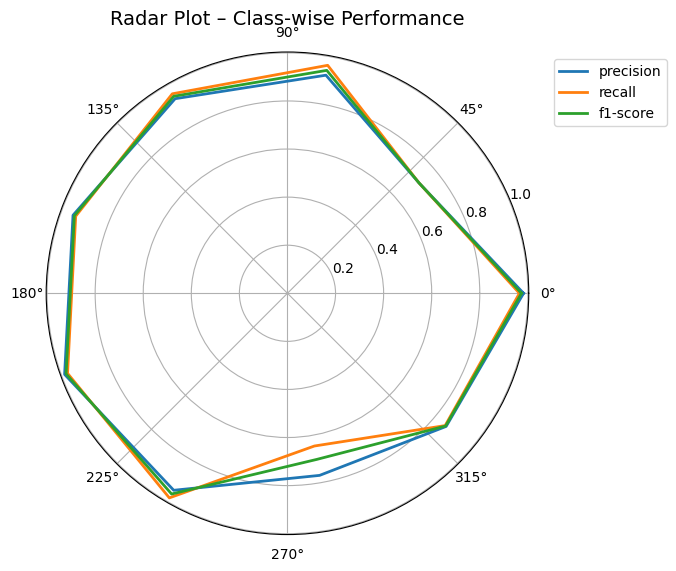

/tmp/ipython-input-3215125541.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=encoder.classes_, y=f1_scores, palette='viridis')


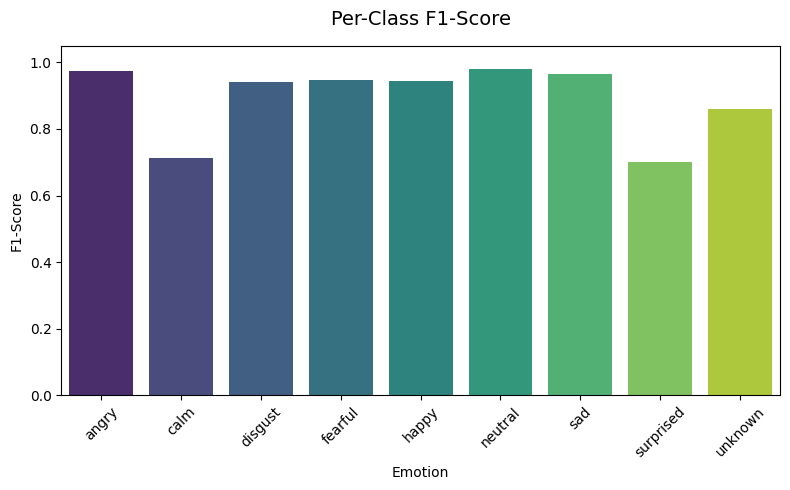

In [ ]:
# ===============================================
# 🎯 Model Performance Visualization – CNN-LSTM (Focal + SMOTE)
# ===============================================
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from math import pi

# -----------------------------
# Radar Plot for Precision, Recall, F1
# -----------------------------
report = classification_report(y_test, y_pred, target_names=encoder.classes_, output_dict=True)
metrics = ['precision', 'recall', 'f1-score']
angles = np.linspace(0, 2*np.pi, len(encoder.classes_), endpoint=False).tolist()
angles += angles[:1]

plt.figure(figsize=(7, 7))
for m in metrics:
    values = [report[c][m] for c in encoder.classes_]
    values += values[:1]
    plt.polar(angles, values, label=m, linewidth=2)
plt.title('Radar Plot – Class-wise Performance', fontsize=14, pad=20)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1))
plt.tight_layout()
plt.show()

# -----------------------------
# Bar Plot (F1 per Class)
# -----------------------------
f1_scores = [report[c]['f1-score'] for c in encoder.classes_]
plt.figure(figsize=(8, 5))
sns.barplot(x=encoder.classes_, y=f1_scores, palette='viridis')
plt.title('Per-Class F1-Score', fontsize=14, pad=15)
plt.xlabel('Emotion'); plt.ylabel('F1-Score')
plt.ylim(0, 1.05)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
# Save CNN-LSTM Model + Label Encoder to Drive
import pickle
import shutil
import os
from sklearn.preprocessing import LabelEncoder

# Recreate or reload your label encoder
label_encoder = LabelEncoder()
label_encoder.fit(y)   # 'y' = your emotion label array (same used during training)

# Folder to save
save_dir = "/content/drive/MyDrive/SpchEmtnDctn/ModelFiles"
os.makedirs(save_dir, exist_ok=True)

# Save Model
model_path = os.path.join(save_dir, "cnn_lstm_emotion_model.h5")
model.save(model_path)
print(f" Model saved to: {model_path}")

# Save Label Encoder
label_path = os.path.join(save_dir, "label_encoder.pkl")
with open("label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder, f)

# Move encoder to Drive
shutil.move("label_encoder.pkl", label_path)
print(f"Label encoder saved to: {label_path}")


✅ Model saved to: /content/drive/MyDrive/SpchEmtnDctn/ModelFiles/cnn_lstm_emotion_model.h5
✅ Label encoder saved to: /content/drive/MyDrive/SpchEmtnDctn/ModelFiles/label_encoder.pkl


# **Optimized CNN + Transformer Encoder**

In [ ]:
# Optimized CNN + Transformer Hybrid (Auto-compatible)

import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report

# Transformer Encoder Block
def transformer_encoder(inputs, num_heads, ff_dim, dropout=0.3):
    attn_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=ff_dim)(inputs, inputs)
    attn_output = layers.Dropout(dropout)(attn_output)
    out1 = layers.LayerNormalization(epsilon=1e-6)(inputs + attn_output)

    ffn = models.Sequential([
        layers.Dense(ff_dim, activation="relu"),
        layers.Dense(inputs.shape[-1])
    ])
    ffn_output = ffn(out1)
    ffn_output = layers.Dropout(dropout)(ffn_output)
    return layers.LayerNormalization(epsilon=1e-6)(out1 + ffn_output)

# Auto reshape to 3D
if len(X_train.shape) == 2:
    timesteps = 10
    n_features = X_train.shape[1] // timesteps
    X_train = X_train.reshape((X_train.shape[0], timesteps, n_features))
    X_test = X_test.reshape((X_test.shape[0], timesteps, n_features))
else:
    timesteps = X_train.shape[1]
    n_features = X_train.shape[2]

num_classes = len(np.unique(y_train))

# Model
inputs = layers.Input(shape=(timesteps, n_features))

# CNN extractor
x = layers.Conv1D(128, 3, padding='same', activation='relu')(inputs)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling1D(2)(x)
x = layers.Dropout(0.3)(x)

# Transformer layers
x = transformer_encoder(x, num_heads=4, ff_dim=128, dropout=0.3)
x = transformer_encoder(x, num_heads=4, ff_dim=128, dropout=0.3)

# Dense head
x = layers.GlobalAveragePooling1D()(x)
x = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

model = models.Model(inputs, outputs)

# Focal Loss
def focal_loss(gamma=2.0, alpha=0.25):
    def loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)
        cross_entropy = -y_true * tf.math.log(y_pred)
        weight = alpha * tf.pow(1 - y_pred, gamma)
        return tf.reduce_mean(tf.reduce_sum(weight * cross_entropy, axis=1))
    return loss

# Compile & Train
optimizer = tf.keras.optimizers.AdamW(learning_rate=3e-5, weight_decay=1e-5)
model.compile(optimizer=optimizer, loss=focal_loss(), metrics=['accuracy'])

y_train_cat = tf.keras.utils.to_categorical(y_train, num_classes)
y_test_cat  = tf.keras.utils.to_categorical(y_test, num_classes)

class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weights = dict(enumerate(class_weights))

early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)
reduce_lr  = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6)

history = model.fit(
    X_train, y_train_cat,
    epochs=40,
    batch_size=64,
    validation_split=0.2,
    class_weight=class_weights,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# Evaluation
test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)
train_acc = history.history['accuracy'][-1]
print(f"\n✅ Train Accuracy: {train_acc*100:.2f}%")
print(f"✅ Test Accuracy:  {test_acc*100:.2f}%")

y_pred = np.argmax(model.predict(X_test), axis=1)
print("\n📊 Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=[str(c) for c in np.unique(y_train)]))


Epoch 1/40
89/89 ━━━━━━━━━━━━━━━━━━━━ 29s 133ms/step - accuracy: 0.1022 - loss: 0.7237 - val_accuracy: 0.0955 - val_loss: 0.4897 - learning_rate: 3.0000e-05
Epoch 2/40
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.1570 - loss: 0.6473 - val_accuracy: 0.2142 - val_loss: 0.4516 - learning_rate: 3.0000e-05
Epoch 3/40
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.1950 - loss: 0.6220 - val_accuracy: 0.3462 - val_loss: 0.3922 - learning_rate: 3.0000e-05
Epoch 4/40
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.2332 - loss: 0.5264 - val_accuracy: 0.4319 - val_loss: 0.3507 - learning_rate: 3.0000e-05
Epoch 5/40
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.2737 - loss: 0.5046 - val_accuracy: 0.5105 - val_loss: 0.3151 - learning_rate: 3.0000e-05
Epoch 6/40
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.3039 - loss: 0.4824 - val_accuracy: 0.5471 - val_loss: 0.2962 - learning_rate: 3.0000e-05
Epoch 7/40
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.3404 - lo

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## **MODEL COMPARISION**

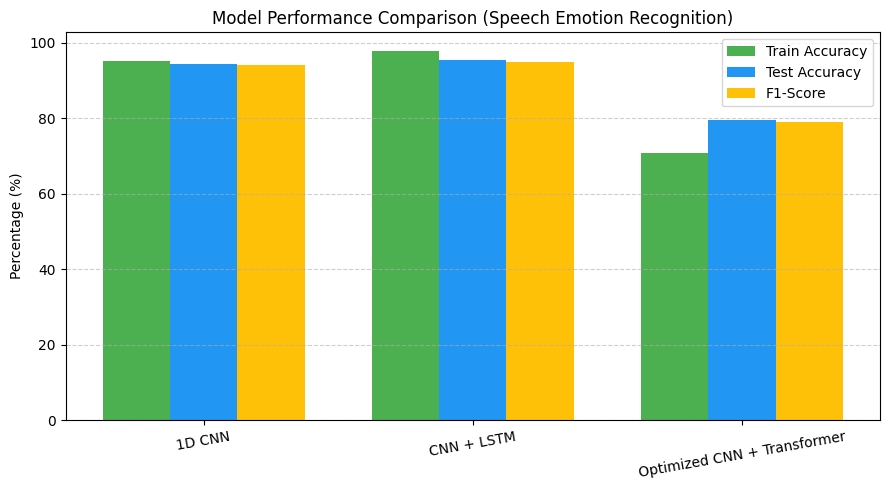

🏆 Top Performing Model: CNN + LSTM (Test Accuracy: 95.36%)


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Model names
models = ['1D CNN', 'CNN + LSTM', 'Optimized CNN + Transformer']

# Accuracy values (%)
train_acc = [95.14, 97.89, 70.67]
test_acc = [94.47, 95.36, 79.60]

# Weighted F1-scores (%)
f1_scores = [94.0, 95.0, 79.0]

# X positions
x = np.arange(len(models))
width = 0.25

# Plot
plt.figure(figsize=(9,5))
plt.bar(x - width, train_acc, width, label='Train Accuracy', color='#4CAF50')
plt.bar(x, test_acc, width, label='Test Accuracy', color='#2196F3')
plt.bar(x + width, f1_scores, width, label='F1-Score', color='#FFC107')

# Labels & styling
plt.xticks(x, models, rotation=10)
plt.ylabel('Percentage (%)')
plt.title('Model Performance Comparison (Speech Emotion Recognition)')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Identify best performing model
best_model = models[np.argmax(test_acc)]
print(f"🏆 Top Performing Model: {best_model} (Test Accuracy: {max(test_acc)}%)")


## **EMOTION DETECTION**

In [ ]:
import numpy as np
import librosa
import pickle
import tensorflow as tf
from keras.utils import custom_object_scope

# Load Model and Encoder
model_path = "/content/drive/MyDrive/SpchEmtnDctn/ModelFiles/cnn_lstm_emotion_model.h5"
encoder_path = "/content/drive/MyDrive/SpchEmtnDctn/ModelFiles/label_encoder.pkl"

with custom_object_scope({}):
    model = tf.keras.models.load_model(model_path, compile=False)

with open(encoder_path, "rb") as f:
    le = pickle.load(f)

# Emotion Labels
emotion_labels = {
    "01": "neutral",
    "02": "calm",
    "03": "happy",
    "04": "sad",
    "05": "angry",
    "06": "fearful",
    "07": "disgust",
    "08": "surprised"
}

# Feature Extraction
def extract_features(audio_path, max_len=26595, numcep=8):
    y, sr = librosa.load(audio_path, sr=None)
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=numcep).T
    if mfccs.shape[0] > max_len:
        mfccs = mfccs[:max_len, :]
    else:
        pad_width = max_len - mfccs.shape[0]
        mfccs = np.pad(mfccs, ((0, pad_width), (0, 0)), mode='constant')
    return mfccs

# Prediction

def predict_emotion(audio_path):
    features = extract_features(audio_path)
    features = np.expand_dims(features, axis=0)

    prediction = model.predict(features)
    pred_index = np.argmax(prediction)
    confidence = np.max(prediction) * 100
    pred_label = le.inverse_transform([pred_index])[0]

    # Find emotion name if numeric
    emotion_name = emotion_labels.get(f"{pred_label:02}", pred_label)

    print(" Audio File:", audio_path)
    print(f" Predicted Emotion: {emotion_name.capitalize()} ({confidence:.2f}%)")

# Test
audio_path = "/content/anger.wav"
predict_emotion(audio_path)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 385ms/step
 Audio File: /content/anger.wav
 Predicted Emotion: Angry (61.95%)
